<a href="https://colab.research.google.com/github/Nicolas-Bernal/Simulacion-Estadistica/blob/main/Primer%20Corte/0_Taller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller Nicolas Alexander Bernal Rubio

# Paula Andrea Castellano

## Simulacion Estadistica

# 1. Aplicar metodo de inversion


---



## **werbull($\alpha$,1)**

### Función de Densidad de Probabilidad (f.d.p.)
Dado $X \sim \text{Weibull}(\alpha, 1)$ para $x > 0$ y $\alpha > 0$:

$$f_X(x) = \alpha x^{\alpha - 1} e^{-x^\alpha}$$

### Función de Distribución Acumulada (F.D.A.)
Integramos la densidad desde el límite inferior $0$ hasta $x$:

$$F_X(x) = \int_{0}^{x} \alpha t^{\alpha - 1} e^{-t^\alpha} \, dt$$

Haciendo el cambio de variable $u = t^\alpha \implies du = \alpha t^{\alpha - 1} dt$:

$$F_X(x) = \int_{0}^{x^\alpha} e^{-u} \, du = \left[ -e^{-u} \right]_{0}^{x^\alpha} = -e^{-x^\alpha} - (-e^0)$$

$$F_X(x) = 1 - e^{-x^\alpha}$$

### Inversión (Despeje de $x$)
Igualamos la F.D.A. a una variable aleatoria uniforme $U \sim \text{Unif}(0,1)$:

$$U = 1 - e^{-x^\alpha}$$

$$e^{-x^\alpha} = 1 - U$$

$$\ln(e^{-x^\alpha}) = \ln(1 - U)$$

$$-x^\alpha = \ln(1 - U)$$

$$x^\alpha = -\ln(1 - U)$$

$$x = \left(-\ln(1 - U)\right)^{\frac{1}{\alpha}}$$

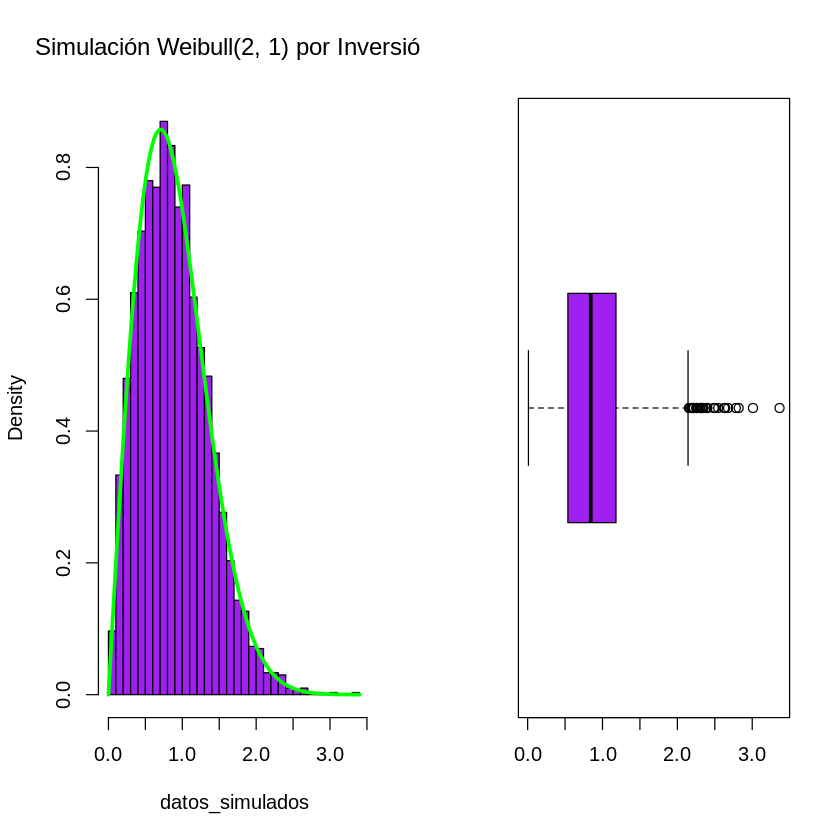

In [ ]:
geneweibull = function(nsim, alpha) {
  u = runif(nsim)
  x = (-log(u))^(1 / alpha)
  return(x)
}

nsim = 3000

alpha = 2
datos_simulados = geneweibull(nsim, alpha)

par(mfrow = c(1,2))
hist(datos_simulados, freq = FALSE, breaks = "FD", col = "purple",main = substitute(paste("Simulación Weibull(", alpha, ", 1) por Inversión"), list(alpha = alpha)))
curve(dweibull(x, shape = alpha, scale = 1), add = TRUE, col = "green", lwd = 3)
boxplot(datos_simulados, horizontal = TRUE,col = "purple")

## Observaciones

* Graficamente se puede observar que la funcion con que contruimos con el metodo inverso esta generando los datos esperados con una distribucion werbull

## **Gumbel(0,1)**

### Función de Densidad de Probabilidad (f.d.p.)
Dado $X \sim \text{Gumbel}(0, 1)$:

$$f_X(x) = e^{-x} e^{-e^{-x}}$$

### Función de Distribución Acumulada (F.D.A.)
Integramos la densidad desde $-\infty$ hasta $x$:

$$F_X(x) = \int_{-\infty}^{x} e^{-t} e^{-e^{-t}} \, dt$$

Haciendo el cambio de variable $u = e^{-t} \implies du = -e^{-t} dt$:
* Cuando $t \to -\infty \implies u \to \infty$
* Cuando $t = x \implies u = e^{-x}$

$$F_X(x) = \int_{\infty}^{e^{-x}} -e^{-u} \, du = \int_{e^{-x}}^{\infty} e^{-u} \, du = \left[ -e^{-u} \right]_{e^{-x}}^{\infty} = 0 - (-e^{-e^{-x}})$$

$$F_X(x) = e^{-e^{-x}}$$

### Inversión (Despeje de $x$)
Igualamos la F.D.A. a una variable aleatoria uniforme $U \sim \text{Unif}(0,1)$:

$$U = e^{-e^{-x}}$$

Aplicamos logaritmo natural ($\ln$) en ambos lados:

$$\ln(U) = -e^{-x}$$

Multiplicamos por $-1$:

$$-\ln(U) = e^{-x}$$

Aplicamos logaritmo natural nuevamente:

$$\ln(-\ln(U)) = -x$$

Despejamos $x$:

$$x = -\ln(-\ln(U))$$

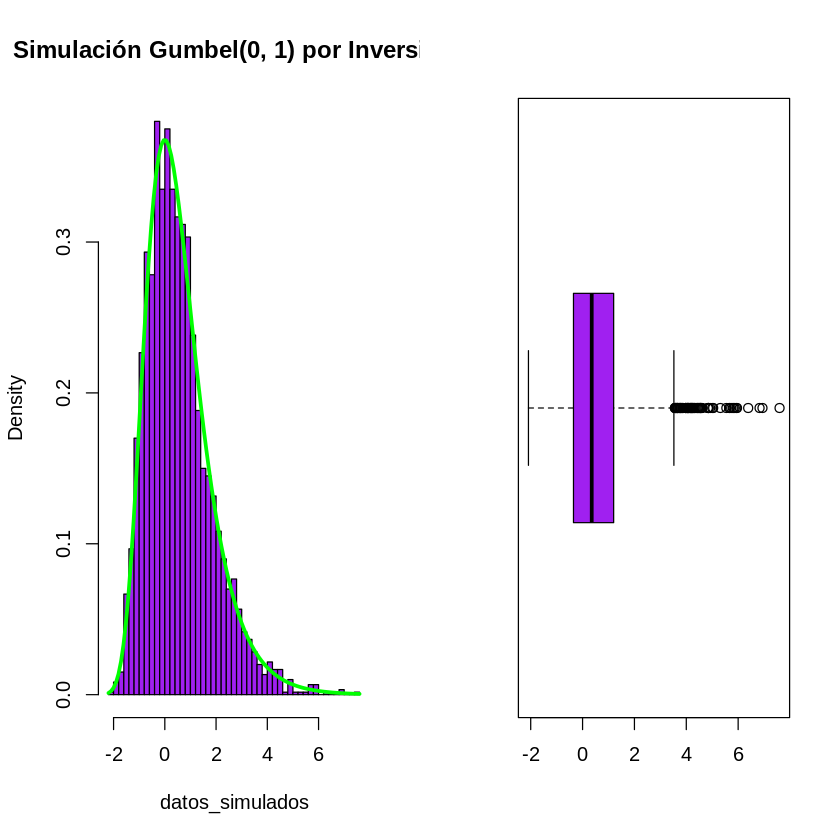

In [ ]:
genergumbel = function(nsim) {
  u = runif(nsim)
  x = -log(-log(u))
  return(x)
}

nsim = 3000
datos_simulados = genergumbel(nsim)

dgumbel_n = function(x) {
  exp(-x) * exp(-exp(-x))
}

par(mfrow = c(1,2))
hist(datos_simulados, freq = FALSE, breaks = "FD", col = "purple",main = "Simulación Gumbel(0, 1) por Inversión")
curve(dgumbel_n(x), add = TRUE, col = "green", lwd = 3)
boxplot(datos_simulados,horizontal = TRUE,col = "purple")

## Observaciones

* Graficamente se puede observar que la funcion con que contruimos con el metodo inverso esta generando los datos esperados con una distribucion gumbel

## Pareto($\alpha$)

### Función de Densidad de Probabilidad (f.d.p.)
Dado $X \sim \text{Pareto}(\alpha, 1)$ para $x \ge 1$ y $\alpha > 0$:

$$f_X(x) = \frac{\alpha}{x^{\alpha + 1}}$$

### Función de Distribución Acumulada (F.D.A.)
Integramos la densidad desde el límite inferior $1$ hasta $x$:

$$F_X(x) = \int_{1}^{x} \frac{\alpha}{t^{\alpha + 1}} \, dt = \int_{1}^{x} \alpha t^{-\alpha - 1} \, dt$$

$$F_X(x) = \left[ -t^{-\alpha} \right]_{1}^{x} = -x^{-\alpha} - (-1^{-\alpha})$$

$$F_X(x) = 1 - x^{-\alpha}$$

### Inversión (Despeje de $x$)
Igualamos la F.D.A. a una variable aleatoria uniforme $U \sim \text{Unif}(0,1)$:

$$U = 1 - x^{-\alpha}$$

$$x^{-\alpha} = 1 - U$$

Elevamos ambos lados a la potencia $-\frac{1}{\alpha}$:

$$(x^{-\alpha})^{-\frac{1}{\alpha}} = (1 - U)^{-\frac{1}{\alpha}}$$

$$x = (1 - U)^{-\frac{1}{\alpha}} = \frac{1}{(1 - U)^{\frac{1}{\alpha}}}$$


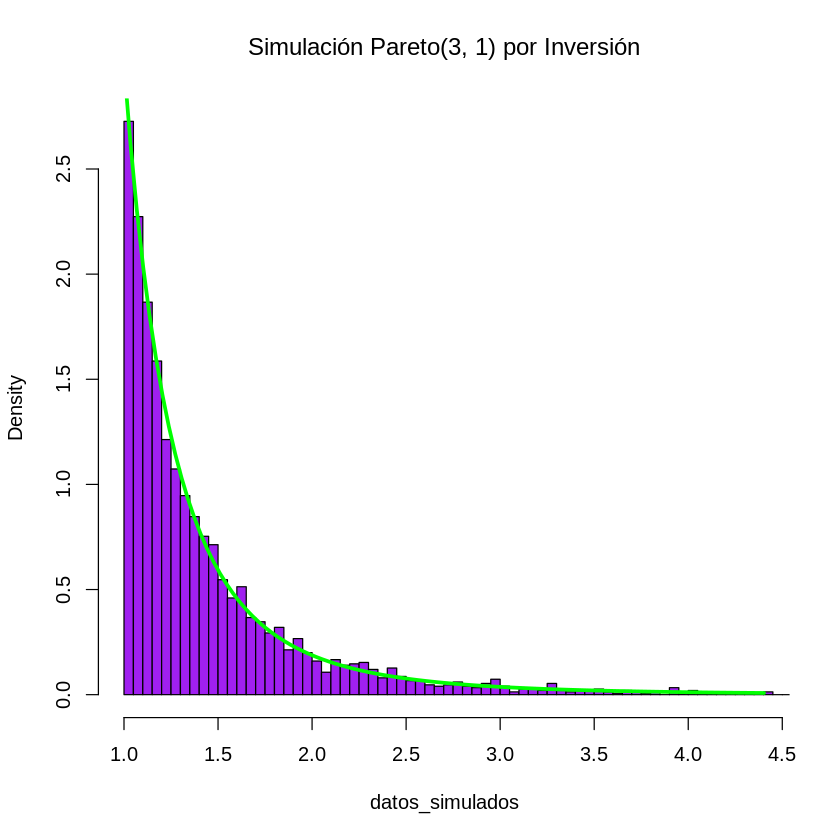

In [ ]:
gen_pareto_inversion <- function(nsim, alpha) {
  u <- runif(nsim)
  x <- (1 - u)^(-1 / alpha)
  return(x)
}
dpareto_n = function(x, alpha) {
  ifelse(x >= 1, alpha / (x^(alpha + 1)), 0)
}

nsim = 3000
alpha = 3
datos_simulados = gen_pareto_inversion(nsim, alpha)


hist(datos_simulados, freq = FALSE, breaks = "FD",col = "purple",xlim = c(1, quantile(datos_simulados, 0.99)),main = substitute(paste("Simulación Pareto(", alpha, ", 1) por Inversión"), list(alpha = alpha)))

curve(dpareto_std(x, alpha), add = TRUE, col = "green", lwd = 3)

## Observaciones

* Graficamente se puede observar que la funcion con que contruimos con el metodo inverso esta generando los datos esperados con una distribucion pareto

# Ejercicios Clase 8/09/2026, 10:00 - 12:00

In [51]:
install.packages("car")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’




## $7)$

Sean $z_1, z_2, \dots, z_n$ variables aleatorias independientes e idénticamente distribuidas (**i.i.d.**) tales que:

$$z_i \sim \mathcal{N}(0,1), \quad \forall i = 1, \dots, n$$

Definimos la variable aleatoria $X$ como:

$$X = \sum_{i=1}^{n} z_i^2 \sim \bar{x}_n^2$$

donde $n \in \mathbb{Z}^+$ representa el tamaño de la muestra y $\bar{x}_n = \frac{1}{n}\sum_{i=1}^{n} z_i$ es la media muestral.

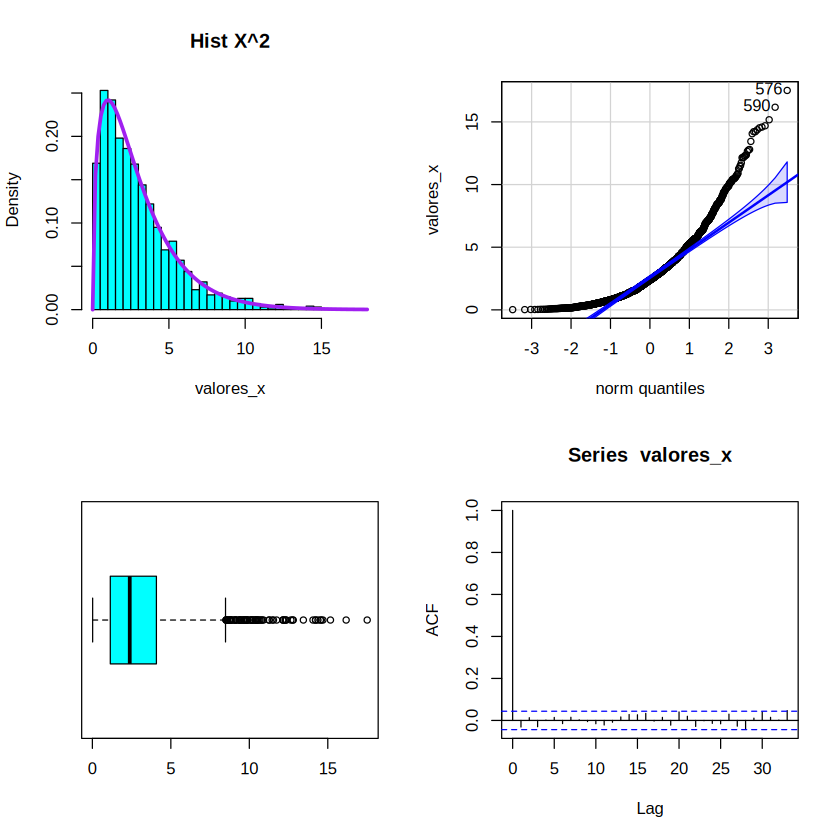

In [67]:
library("car")

chi = function(n,nsim){
  matrix1 = matrix(rnorm(n * nsim),nrow = nsim,ncol = n)

  valores_x = rowSums(matrix1^2)

  par(mfrow = c(2,2))
  hist(valores_x,freq = FALSE,breaks = "FD",col = "cyan",main = "Hist X^2")
  curve(dchisq(x,df = n),add = TRUE,lwd = 3,col = "purple")
  qqPlot(valores_x)
  boxplot(valores_x,horizontal = TRUE,col = "cyan")
  acf(valores_x)

}

chi(3,2000)

### Observaciones

* El ajuste entre el histograma empírico y la curva teórica (morada) confirma visualmente que la suma de variables normales al cuadrado sigue la distribución Chi-cuadrado esperada
* La curvatura pronunciada respecto a la línea azul recta demuestra claramente que los datos simulados no siguen una distribución Normal

* Muestra una marcada asimetría hacia la derecha con la mediana sesgada hacia la izquierda (cerca de $x = 2$) y una alta concentración de datos atípicos o extremos hacia la derecha (valores por encima de $8$), lo cual es característico del comportamiento de la distribución Chi-cuadrado

* a ausencia de barras significativas fuera de las bandas de confianza de decisión (a excepción del rezago $0$) valida la independencia estadística entre las simulaciones generadas

## $8)$

ean $z$ e $y$ dos variables aleatorias **independientes** tales que:

$$z \sim \mathcal{N}(0,1)$$
$$y \sim \chi_n^2$$

Definimos la variable aleatoria $X$ como:

$$X = \frac{z}{\sqrt{y / n}}$$

Entonces, la variable $X$ se distribuye como una **t de Student con $n$ grados de libertad**:

$$X \sim t_n$$

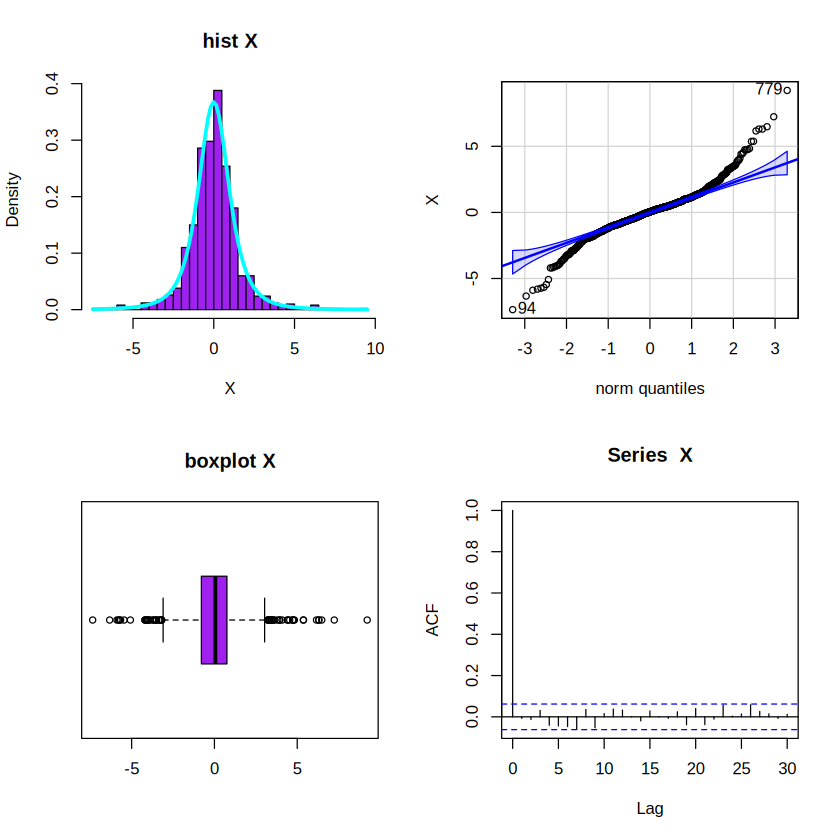

In [80]:
t = function(n,nsim){
  z = rnorm(nsim)
  y = rchisq(nsim,df = n)

  X = z/sqrt(y/n)

  par(mfrow = c(2,2))
  hist(X,freq = FALSE,breaks = "FD",col = "purple",main = "hist X")
  curve(dt(x,df = n),add = TRUE,lwd = 3,col = "cyan")
  qqPlot(X)
  boxplot(X,horizontal = TRUE,col = "purple",main = "boxplot X")
  acf(X)
}

t(3,1000)

### Observaciones

* Las barras moradas siguen de forma precisa la curva de densidad cian $t(df = 3)$. Muestra una distribución acampanada, centrada en $0$ y con colas más pesadas que las de una Normal Estándar, lo que confirma que la relación $X = \frac{z}{\sqrt{y/n}}$ genera la distribución $t$ de Student esperada

* La forma de "S" pronunciada (los puntos se desvían de la línea recta azul tanto en la cola izquierda como en la derecha) demuestra que los datos tienen colas más pesadas que una Normal Estándar. Esto es totalmente correcto, pues la distribución $t_n$ asigna mayor probabilidad a valores extremos que la Normal

* El gráfico es simétrico con respecto a $0$ (su mediana está centrada), pero exhibe una cantidad considerable de valores atípicos en ambas direcciones (valores $< -3$ y $> 3$). Esto respalda de nuevo la presencia de colas pesadas debidas a los pocos grados de libertad ($n = 3$).

* Salvo el primer rezago, ninguna de las barras de autocorrelación sobrepasa las bandas de confianza punteadas en azul. Esto valida que las simulaciones generadas son numéricamente independientes entre sí y no presentan dependencia temporal

## $9)$

Sean $y_1$ e $y_2$ dos variables aleatorias **independientes** tales que:

$$y_1 \sim \chi_{n_1}^2 \quad \text{y} \quad y_2 \sim \chi_{n_2}^2$$

Definimos la variable aleatoria $X$ como el cociente de ambas variables divididas por sus respectivos grados de libertad:

$$X = \frac{y_1 / n_1}{y_2 / n_2}$$

Entonces, $X$ sigue una **distribución F de Snedecor** con $n_1$ y $n_2$ grados de libertad:

$$X \sim F_{n_1, n_2}$$

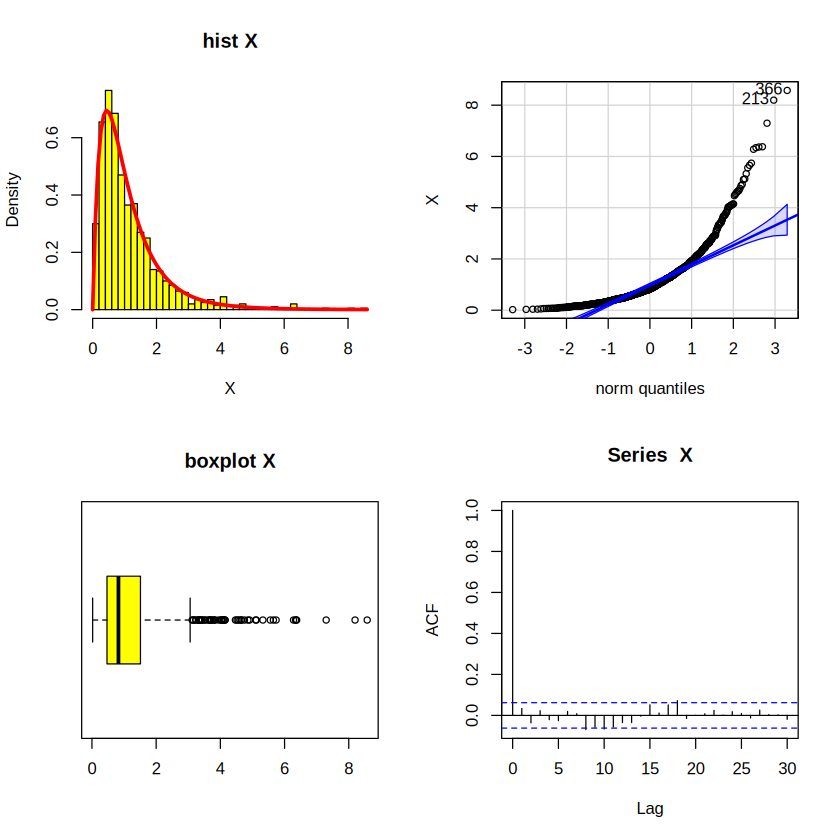

In [91]:
Fi = function(n1,n2,nsim){
  y1 = rchisq(nsim,df = n1)
  y2 = rchisq(nsim,df = n2)

  X = (y1/n1)/(y2/n2)

  par(mfrow = c(2,2))
  hist(X,freq = FALSE,breaks = "FD",col = "yellow",main = "hist X")
  curve(df(x,df1 = n1,df2 = n2),add = TRUE,lwd = 3,col = "red")
  qqPlot(X)
  boxplot(X,horizontal = TRUE,col = "yellow",main = "boxplot X")
  acf(X)

}

Fi(4,15,1000)

### Observaciones

* Histograma (Arriba a la izquierda): Las barras amarillas encajan perfectamente con la línea roja. Esto nos dice de forma súper visual que la fórmula funciona: al dividir las dos Chi-cuadrado ajustadas, los datos caen exactamente donde la teoría de la distribución F dice que deberían caer. Además, no hay valores negativos porque estás dividiendo números positivos.

* La línea de puntos se dispara hacia arriba al final y no sigue la línea recta azul. Esto es una prueba clarísima de que estos datos para nada son una Normal. Se curva así porque la distribución F tiene una "cola" muy larga hacia la derecha.

* La caja está apretada cerca del 1 y tiene un montón de puntos sueltos hacia la derecha (que llegan hasta el 8 o 9). Esto te muestra que la mayoría de los resultados son números pequeños, pero de vez en cuando la división da un salto y genera valores bastante altos

* Todas las barras (menos la primera, que siempre es 1) están dentro de las líneas punteadas azules. En español sencillo: cada dato que simulaste es completamente independiente del anterior, no hay ningún patrón ni "trampa" en cómo R generó los números aleatorios.

## Algoritmo Box-Muller

El algoritmo de Box-Muller transforma dos variables aleatorias independientes distribuidas uniformemente en el intervalo $(0, 1)$ para generar un par de variables aleatorias independientes que siguen una distribución normal estándar $N(0, 1)$.

* a)  Generar $U_1,U_2 - N(0,1) $

* b)  Hacer $R = \sqrt-2ln(U_1), \theta = 2\pi U_2$

* c)  hacer $X = Rcos(\theta), Y = Rsen(\theta)$

* d)  $X - N(0,1), Y - N(0,1)$, ademas X y Y son independientes

In [ ]:
install.packages("car")

In [ ]:
# algoritmo Box-Muller
library(car)

box_muller = function(nsim){
  x = rep(0,nsim)
  y = rep(0,nsim)

  for(i in 1:nsim){

    u1 = runif(nsim)
    u2 = runif(nsim)

    R = sqrt(-2*log(u1))
    theta = 2*pi*u2

    x[i] = R*cos(theta)
    y[i] = R*sin(theta)
  }
  return(list(x = x,y = y))
}

X_salida = box_muller(1000)$x

Y_salida = box_muller(1000)$y

[1] 254 529


	Shapiro-Wilk normality test

data:  X_salida
W = 0.99883, p-value = 0.7769


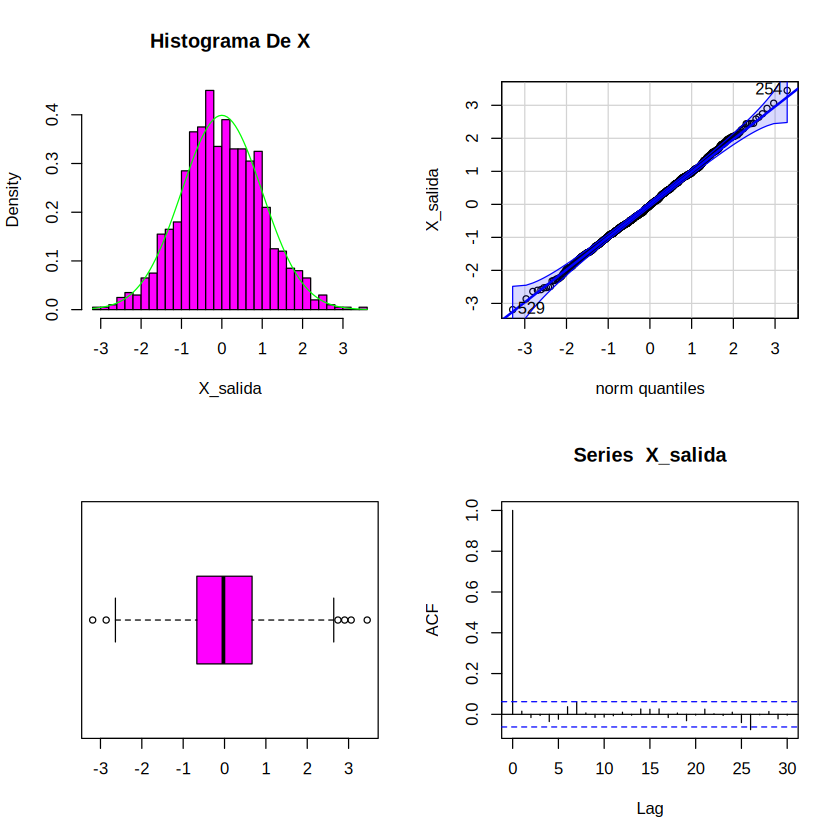

In [93]:
# Graficas y pruebas de X ~ N(0,1), Y ~ N(0,1)

par(mfrow = c(2,2))
hist(X_salida,freq = FALSE,breaks = "FD",col = "magenta",main = "Histograma De X")
curve(dnorm(x),add = TRUE,col = "green")
qqPlot(X_salida)
boxplot(X_salida,horizontal = TRUE,col = "magenta")
acf(X_salida)

shapiro.test(X_salida) #para mi semilla me da un p-value = 0.293 por lo que se acepta la hipotesis nula

[1]  37 111


	Shapiro-Wilk normality test

data:  Y_salida
W = 0.99889, p-value = 0.8085


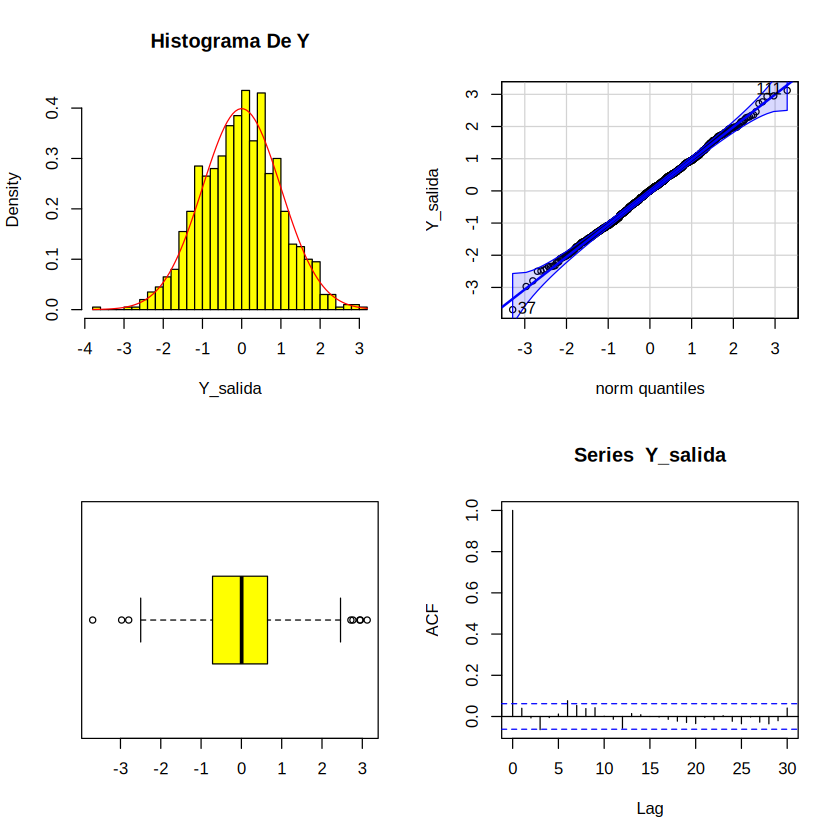

In [94]:
par(mfrow = c(2,2))
hist(Y_salida,freq = FALSE,breaks = "FD",col = "yellow",main = "Histograma De Y")
curve(dnorm(x),add = TRUE,col = "red")
qqPlot(Y_salida)
boxplot(Y_salida,horizontal = TRUE,col = "yellow")
acf(Y_salida)

shapiro.test(Y_salida) #para mi semilla me da un p-value = 0.1388 por lo que se acepta la hipotesis nula

### Eficiencia-Computacional



In [95]:
# system.time


tX = system.time(box_muller(1000)$X)
tY = system.time(box_muller(1000)$Y)
# eficiencia computacional comparando


t0 = proc.time()
box_muller(1000)$X
t1x = proc.time() - t0



t0 = proc.time()
box_muller(1000)$Y
t1y = proc.time() - t0

# comparacion proc vs system

tX
t1x

tY
t1y

Se han truncado las últimas 5000 líneas del flujo de salida.
Warning message in x[i] <- R * cos(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in y[i] <- R * sin(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in x[i] <- R * cos(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in y[i] <- R * sin(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in x[i] <- R * cos(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in y[i] <- R * sin(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in x[i] <- R * cos(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in y[i] <- R * sin(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in x[i] <- R * cos(theta):


NULL

Warning message in x[i] <- R * cos(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in y[i] <- R * sin(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in x[i] <- R * cos(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in y[i] <- R * sin(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in x[i] <- R * cos(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in y[i] <- R * sin(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in x[i] <- R * cos(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in y[i] <- R * sin(theta):
“number of items to replace is not a multiple of replacement length”
Warning message in x[i] <- R * cos(theta):
“number of items to replace is not a multiple of replacement 

NULL

   user  system elapsed 
  7.272   0.176   7.688 

   user  system elapsed 
  7.396   0.149   7.790 

   user  system elapsed 
  7.459   0.163   8.511 

   user  system elapsed 
  7.361   0.155   8.104 

### Observaciones

*  El ajuste perfecto de las barras del histograma y del Q-Q Plot sobre la curva Normal teórica demuestra que el algoritmo de Box-Muller transforma con total precisión dos variables Uniformes $(0,1)$ en Normales Estándar $\mathcal{N}(0,1)$; sin embargo, al depender de funciones trascendentales computacionalmente costosas ($\ln$, $\sin$, $\cos$), su costo computacional suele presentar un tiempo de ejecución ligeramente mayor frente a métodos optimizados como el algoritmo Ziggurat o la variante polar de Marsaglia

## Marsaglia


El **método de Marsaglia** (o transformación de *Marsaglia-Bray*) es una modificación del algoritmo de Box-Muller diseñada para evitar el cálculo de funciones trigonométricas ($\cos$ y $\sin$), las cuales son computacionalmente costosas.


En lugar de generar un ángulo $\theta$ directamente con $2\pi U_2$, Marsaglia utiliza un método de **aceptación y rechazo** en el círculo unitario:

1. Genera dos variables uniformes independientes $V_1, V_2 \sim \text{Unif}(-1, 1)$.
2. Calcula la distancia al cuadrado desde el origen: $S = V_1^2 + V_2^2$.
3. Si $S \ge 1$ o $S = 0$, se descarta el punto y se vuelve a intentar (aceptamos solo puntos dentro del círculo unitario de radio 1).
4. Dentro del círculo unitario, los cocientes $\frac{V_1}{\sqrt{S}}$ y $\frac{V_2}{\sqrt{S}}$ representan exactamente el coseno y seno de un ángulo uniforme.

Sustituyendo estas relaciones en la fórmula original de Box-Muller, se obtienen las expresiones finales:

$$Z_1 = V_1 \sqrt{\frac{-2 \ln(S)}{S}}$$

$$Z_2 = V_2 \sqrt{\frac{-2 \ln(S)}{S}}$$

In [96]:
# algoritmo de masaglia

masaglia = function(nsim){
  X = rep(0,nsim)
  Y = rep(0,nsim)

  for(i in 1:nsim){
    w = 2
    while ( w>1 || w==0){
      u1 = runif(1)
      u2 = runif(1)

      v1 = 2*u1-1
      v2 = 2*u2-1

      w = v1^2 + v2^2
    }
    c = sqrt((-2 * log(w)) / w)

    X[i] = c * v1
    Y[i] = c * v2
  }

  return(list(x = X, y = Y))
}

X = masaglia(2000)$x
Y = masaglia(2000)$y

[1] 879 510


	Shapiro-Wilk normality test

data:  X
W = 0.99882, p-value = 0.198


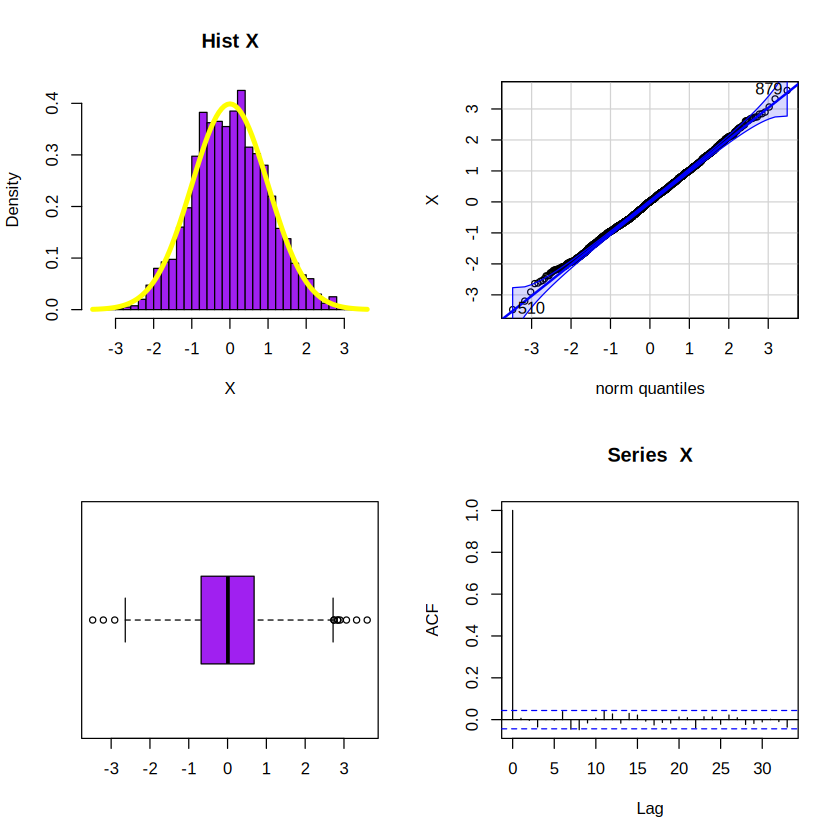

In [97]:
# graficos y pruebas

par(mfrow = c(2,2))
hist(X,freq = FALSE,breaks = "FD",col = "purple",main = "Hist X")
curve(dnorm(x),add = TRUE,col = "yellow",lwd = 4)
qqPlot(X)
boxplot(X,horizontal = TRUE,col = "purple")
acf(X)

shapiro.test(X)

[1]  777 1581


	Shapiro-Wilk normality test

data:  Y
W = 0.99779, p-value = 0.007128


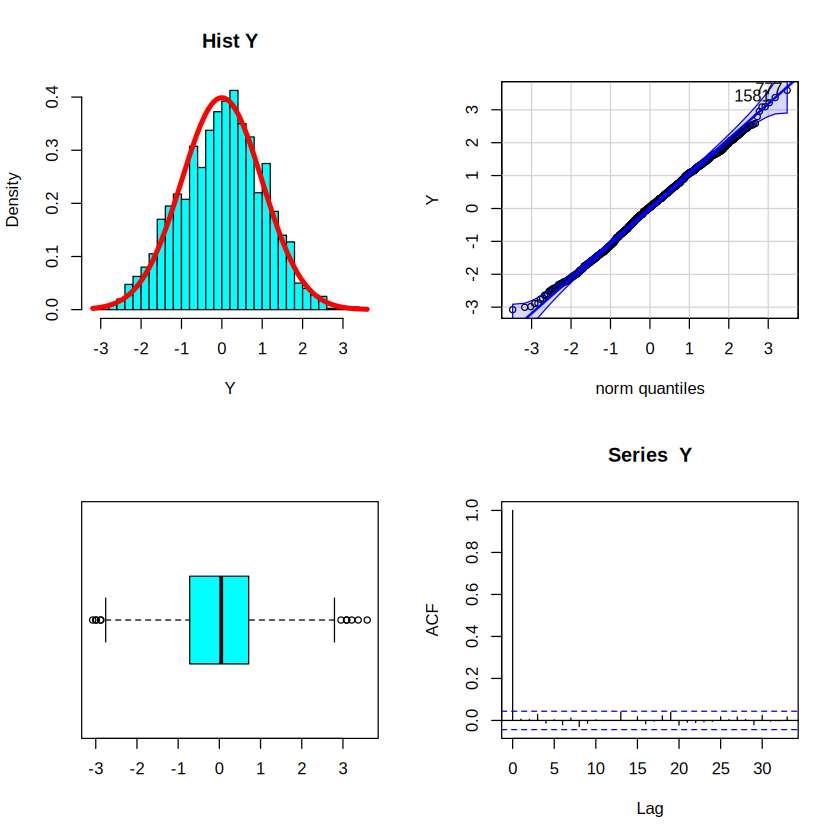

In [98]:
par(mfrow = c(2,2))
hist(Y,freq = FALSE,breaks = "FD",col = "cyan",main = "Hist Y")
curve(dnorm(x),add = TRUE,col = "red",lwd = 4)
qqPlot(Y)
boxplot(Y,horizontal = TRUE,col = "cyan")
acf(Y)

shapiro.test(Y)

### Eficiencia-Computacional

In [99]:
tX = system.time(masaglia(1000)$x)
tY = system.time(masaglia(1000)$y)
# eficiencia computacional comparando


t0 = proc.time()
masaglia(1000)$x
t1x = proc.time() - t0



t0 = proc.time()
masaglia(1000)$y
t1y = proc.time() - t0

# comparacion proc vs system

tX
t1x

tY
t1y

[1]  1.007100182  0.512020261  0.281561637 -0.515173975  1.611835569
   [6] -0.128742652  1.304150265 -0.054654543  1.103346592  0.324768188
  [11] -0.534229072 -2.082268293 -0.590561975 -0.388281279  0.712103707
  [16]  0.566009458  0.898017977  0.172333857 -1.176513356 -0.714944685
  [21]  1.876328375  1.663289409 -2.439212075 -0.014599650 -0.442413089
  [26]  0.264443990 -2.129070698 -0.149720069 -0.326201755  0.836778004
  [31] -1.302813708  0.157917280  0.175768718  0.275323271 -1.418464417
  [36] -0.312645333 -0.226359889  0.130359302  1.184540310 -0.051430862
  [41] -2.062574525  0.053636112 -0.563374255 -0.367987099 -1.251462640
  [46] -0.349560116 -0.361939785 -0.398255143 -0.385892818 -0.007909163
  [51]  0.517258057  1.588180630  1.882953024  0.277226720 -0.710310175
  [56]  0.148191630 -0.691271533  1.240508946 -2.508961406 -1.191220793
  [61] -2.120948506  0.422211438  0.994624133 -1.840828793  0.319864718
  [66] -0.038431825 -0.758971500 -1.465053589 -1.051945780 -0.087282757
  [71] -1.038392754  0.615625262 -0.472517871  0.429611017  0.577114990
  [76] -0.523630497  0.436182756 -0.410876738 -2.067185858 -0.693131211
  [81] -0.201734585 -0.394068677 -1.457826844  0.180107646  1.193490504
  [86]  0.038048364  0.931448846 -0.362716614  1.859167836 -0.834422017
  [91]  1.661950407 -0.259349472 -0.845294981  0.662712927 -0.793325203
  [96] -1.531844050 -1.105919078 -0.290868575  1.157089143  0.303838508
 [101] -0.737813472  1.813553856 -0.440825464 -0.266942145  0.273646716
 [106] -1.237421184  0.879549037  1.082762188 -0.551356359  0.555412358
 [111] -0.521933475  1.666835813 -0.773625590 -1.362773819  0.358004990
 [116]  0.630080303  0.875589233 -0.098149182  1.473476995  0.229660203
 [121] -0.931478023  1.143181029  0.404291520 -1.312872942 -0.001614464
 [126]  0.571605289  0.089845986 -0.491970392 -0.121110890  0.339765801
 [131]  0.273840388  1.137741013 -0.846015212 -2.063498892  1.195770362
 [136] -0.647464246  1.348857840  0.064402172 -0.480255528  0.011639588
 [141]  0.119421648  1.680732342  0.472684502 -1.765978177  0.691219083
 [146]  0.667971611 -1.160126738 -1.701616945 -0.250490427  2.416009206
 [151]  2.064381476 -0.195104834  3.207894022  0.098637185  0.155607397
 [156]  1.099789356 -0.963838136 -0.477677269  1.599071237  1.769729468
 [161]  0.096920402 -1.739222078 -1.217468729  0.371761943 -0.991219438
 [166]  1.853628111  0.130553729 -0.635983205 -1.220438115  2.674411803
 [171]  1.609365188  1.116937921 -1.028924897 -0.671216627 -2.654418346
 [176] -0.497686549 -1.031844179 -0.344419440 -1.680312175  0.870797440
 [181] -0.680709525  1.026666267  1.188610090  0.005291031 -0.657424313
 [186]  0.599882032 -0.335342431 -0.498169399 -2.717020585 -1.590588680
 [191]  1.651000246  0.103866074  0.177978141  0.944671739  0.312507866
 [196] -0.300716664  0.748264388  1.508545400  0.869955726 -1.342574161
 [201]  0.331294096  0.435852705 -0.044392828  0.367213438  0.805087833
 [206] -0.211649560  0.113611721  0.020904650  1.379626781  0.714822263
 [211] -0.572248888 -0.319750983  1.551672998  1.639979062  0.244067481
 [216] -1.209718323  0.190246422  0.310638631 -0.978832082 -1.249979084
 [221]  0.108571624  0.741433442  1.972974291  2.135647813  0.611710833
 [226] -1.132937845 -0.016234065  0.158759256  0.337854709 -0.206045192
 [231]  3.001004488 -0.838206142 -2.966605174  2.658027523 -2.158634148
 [236] -0.565077797 -0.002124948 -0.586938883 -0.419184333 -0.350859366
 [241]  1.334052308 -0.701843182  1.048905675  0.016078091 -0.244824349
 [246] -2.457102546  0.410483604 -1.098606011  0.188571814 -2.957769731
 [251] -1.347978430 -1.171101697 -2.606675472 -0.507321395  0.200259267
 [256] -1.082109685  0.892740319 -0.030646622  0.409508803  1.003215657
 [261] -1.339454351 -0.155210688  0.987661554  0.053910027 -0.558574960
 [266]  1.012660681 -1.990644289 -1.311635660 -0.234699374  0.900072970
 [271]  0.121627349  0.194541851  0.781674436 -2.233614291  0.448682156
 [276] -0.939575118 -0.799983285 -0.3069186

[1] -2.129165905  0.076289400 -0.525360660 -1.646710689  0.438770687
   [6] -0.991081840  1.240560343 -1.005600539 -1.073951067  0.175385865
  [11] -2.191984213  1.570571041  1.022687160  0.237316334  0.074856970
  [16]  0.690202759 -0.090947135  0.384274720 -0.571661391 -0.408171506
  [21]  1.753996640 -1.365202151 -1.212493261  0.718292823 -1.601138199
  [26] -0.539149732  0.009157216 -0.146206075  0.500691875  0.224227716
  [31] -0.301808251  0.909830906  0.716239796  0.342339378 -0.347341567
  [36] -0.442100548 -2.124679539  1.188388270 -1.057737175  0.776152981
  [41] -0.388686579 -0.450328181  0.048525573  1.475821254  2.075883031
  [46]  0.273188670  1.015521677  0.649806803  0.128126924 -0.226168091
  [51]  1.138492732 -0.305895134  0.785142091 -0.271225658  0.139589051
  [56]  0.443609021 -0.391902324  0.454602436  0.315243015  0.144799852
  [61]  0.946338044  0.401076781  0.815916401  1.419363942 -0.253111724
  [66]  0.599506853  0.086275942 -0.640263138  0.557002432  1.950928793
  [71]  0.822593357 -0.470480241  1.166128595 -0.592985581  1.563261776
  [76] -0.446638633 -0.672911180 -1.431522401 -0.203001163  2.182624757
  [81] -1.775850906  1.239500891 -0.417908414  0.242521997 -1.315145798
  [86] -0.707552565 -0.504832259  0.447658991 -1.286842805  2.191611492
  [91] -0.622915247 -0.578251280  0.667624601 -1.760877932  0.041005436
  [96]  1.387497162 -0.918585977 -0.440333792  1.596712455  0.623632218
 [101] -1.180306228  1.068303243  0.710462989  0.549614223 -0.252465195
 [106]  2.109542118 -0.409899901 -0.684309369  0.524400485  0.194057910
 [111]  1.451222481 -1.458586932 -0.293464218 -1.575575103 -0.486829472
 [116] -0.516921151 -0.444246694  1.587168514 -1.224228439 -1.429170976
 [121] -0.094975212 -1.283339321 -1.972907970 -1.646698830  1.061117411
 [126] -0.577784082  0.185090735  0.226348058 -1.337506688  0.881077170
 [131]  0.120387851  2.317680651  0.694093118 -0.500949963  0.567270480
 [136]  1.454654429 -0.401338738 -1.062877742 -1.780527604 -0.171434068
 [141] -1.715150612 -0.559550588  0.668254164 -0.676294068  1.072548677
 [146]  0.035150313 -1.519197545 -2.117011520  0.107008620  0.456893464
 [151] -0.558351966  0.508781901  0.613663353  0.809952393 -1.035992485
 [156]  0.258364049  0.805268948 -0.482504597  0.627679431  1.160220136
 [161]  1.252532929 -0.051112704 -0.576802407 -0.526683363  0.407959588
 [166] -0.834595105 -0.700496646 -0.495662820 -0.124127759 -0.731457941
 [171] -0.844501013  0.859130921  1.057421785 -0.105963584 -0.291576005
 [176]  0.625231592 -0.902573400  0.528570953 -0.619951735 -0.252315491
 [181] -1.053211943  0.706311923 -0.035652924  0.694453513  0.202817237
 [186] -0.636080464 -0.460447223 -0.597521638 -0.230540184  0.333514609
 [191]  0.655462193 -0.381282978  0.065409428 -0.143114999  0.030658683
 [196]  0.403612581 -0.725505191  0.419453320  1.128615325 -0.475034126
 [201]  0.864557435  0.101581948 -0.978955136  0.548781631  1.398348959
 [206] -0.250850704 -1.318530171  1.039792213  1.506147201 -0.017250710
 [211]  1.503605988  1.223078075  0.264151736  1.286071815 -0.341075116
 [216]  0.687402163 -1.240512881 -0.415997134 -0.314791096 -0.080612411
 [221]  1.582815086 -0.321810211 -0.348520715 -0.409315076 -0.507360089
 [226]  1.264023721 -1.264596817  0.025278765 -1.083787770 -0.247010026
 [231] -0.573907789 -0.056917424 -0.655693341 -0.146944301 -1.174361994
 [236]  1.484840385 -0.683401675  0.061056434  0.076656757 -0.683939708
 [241]  0.097088747  0.603812606  0.676212769 -1.661096418  0.346085950
 [246]  1.507702557  0.588618507  0.387226214 -0.512432222 -1.045879024
 [251]  0.480038833  0.843799541 -0.392254802  1.336738262 -1.186651254
 [256]  0.191517251  0.314747011  0.429488261  0.220463489 -1.024778706
 [261] -0.938970377  0.175095047 -0.174847318  0.056675369  0.504112462
 [266]  0.198663862 -1.675918964  0.415157832  1.902431551 -1.314918320
 [271] -0.546819203 -1.052990785  0.600591391 -1.721386409  0.935180297
 [276]  0.192436738 -0.659640711  0.5029947

   user  system elapsed 
  0.004   0.000   0.004 

   user  system elapsed 
  0.018   0.000   0.018 

   user  system elapsed 
  0.004   0.000   0.004 

   user  system elapsed 
  0.019   0.000   0.018 

### Observaciones

* Los gráficos de diagnóstico (histograma y Q-Q Plot) confirman que la variante polar de Marsaglia genera variables Normales Estándar $\mathcal{N}(0,1)$ con perfecta exactitud teórica, logrando evitar las costosas evaluaciones trigonométricas ($\sin$ y $\cos$) del Box-Muller tradicional mediante un muestreo por rechazo en el círculo unitario ($S < 1$) que simplifica la transformación a un escalamiento vectorial directo

## Box-Muller vs Marsaglia

El método de Box-Muller garantiza una transformación analítica biyectiva sin pérdida de muestras, pero su rendimiento está acotado por la latencia del procesador al evaluar aproximaciones polinomiales para senos y cosenos. Por su parte, la variante de Marsaglia sustituye el costo computacional de las funciones trigonométricas por una prueba de aceptación y rechazo geométrica, reduciendo los ciclos de reloj totales a pesar de la tasa de descarte de variables para un coste menor computacionalmente es mejor Marsaglia ya teniendo los tiempos comparados anterior mente sigue siendo demasiado mejor marsaglia